# Customer Lifetime Value (CLV) & Churn Prediction

## Innovexa Catalyst Data Science Case Study

### Objectives

- Predict Customer Lifetime Value (CLV)
- Predict Customer Churn
- Perform Exploratory Data Analysis (EDA)
- Generate Business Insights and Recommendations

Author: Solasa Sahithi Vasavi

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [227]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [228]:
pd.set_option("display.max_columns", None)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [229]:
# Load Datasets
customers = pd.read_csv("../data/customers.csv")
transactions = pd.read_csv("../data/transactions.csv")
events = pd.read_csv("../data/events.csv")
support = pd.read_csv("../data/support_tickets.csv")
churn = pd.read_csv("../data/churn_labels.csv")
clv = pd.read_csv("../data/clv_labels.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [230]:
print("Customers :", customers.shape)
print("Transactions :", transactions.shape)
print("Events :", events.shape)
print("Support :", support.shape)
print("Churn :", churn.shape)
print("CLV :", clv.shape)

Customers : (5000, 7)
Transactions : (42424, 5)
Events : (60206, 4)
Support : (4889, 6)
Churn : (5000, 2)
CLV : (5000, 2)


In [231]:
customers.head()

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee
0,100001,2025-01-31,63,Male,India,Basic,9.99
1,100002,2024-05-10,43,Male,USA,Standard,19.99
2,100003,2025-02-04,65,Male,Canada,Standard,19.99
3,100004,2024-12-31,56,Male,UK,Premium,39.99
4,100005,2024-11-10,58,Male,India,Standard,19.99


In [232]:
transactions.head()

,customer_id,transaction_date,amount,payment_method,is_refund
0,100001,2023-07-07,6.38,PayPal,0
1,100001,2025-05-23,79.78,PayPal,0
2,100001,2024-06-17,20.09,UPI,0
3,100002,2024-07-30,16.23,Card,0
4,100002,2024-11-20,46.87,NetBanking,0


In [233]:
events.head()

,customer_id,event_date,event_type,event_value
0,100001,2022-05-11,share,66.21
1,100001,2022-01-26,watch,15.84
2,100001,2024-12-12,share,82.19
3,100001,2025-10-11,search,83.66
4,100001,2025-02-03,search,12.35


In [234]:
support.head()

,ticket_id,customer_id,ticket_date,ticket_category,resolution_time_hrs,satisfaction_score
0,1,100003,2025-01-15,Billing,47.9,4.5
1,2,100004,2023-11-10,Feature,3.2,2.8
2,3,100004,2025-02-06,Technical,10.5,2.4
3,4,100004,2025-10-07,Account,58.1,3.6
4,5,100007,2023-09-17,Technical,46.4,3.0


In [235]:
churn.head()

,customer_id,churn_30d
0,100001,1
1,100002,0
2,100003,0
3,100004,0
4,100005,0


In [236]:
clv.head()

,customer_id,clv
0,100001,274.01
1,100002,924.84
2,100003,574.05
3,100004,989.17
4,100005,322.91


In [237]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  5000 non-null   int64  
 1   signup_date  5000 non-null   object 
 2   age          5000 non-null   int64  
 3   gender       5000 non-null   object 
 4   country      5000 non-null   object 
 5   plan_type    5000 non-null   object 
 6   monthly_fee  5000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 273.6+ KB


In [238]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42424 entries, 0 to 42423
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       42424 non-null  int64  
 1   transaction_date  42424 non-null  object 
 2   amount            42424 non-null  float64
 3   payment_method    42424 non-null  object 
 4   is_refund         42424 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.6+ MB


In [239]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60206 entries, 0 to 60205
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  60206 non-null  int64  
 1   event_date   60206 non-null  object 
 2   event_type   60206 non-null  object 
 3   event_value  60206 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.8+ MB


In [240]:
support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ticket_id            4889 non-null   int64  
 1   customer_id          4889 non-null   int64  
 2   ticket_date          4889 non-null   object 
 3   ticket_category      4889 non-null   object 
 4   resolution_time_hrs  4889 non-null   float64
 5   satisfaction_score   4889 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 229.3+ KB


In [241]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  5000 non-null   int64
 1   churn_30d    5000 non-null   int64
dtypes: int64(2)
memory usage: 78.2 KB


In [242]:
clv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  5000 non-null   int64  
 1   clv          5000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 78.2 KB


In [243]:
print(customers.isnull().sum())
print(transactions.isnull().sum())
print(events.isnull().sum())
print(support.isnull().sum())
print(churn.isnull().sum())
print(clv.isnull().sum())

customer_id    0
signup_date    0
age            0
gender         0
country        0
plan_type      0
monthly_fee    0
dtype: int64
customer_id         0
transaction_date    0
amount              0
payment_method      0
is_refund           0
dtype: int64
customer_id    0
event_date     0
event_type     0
event_value    0
dtype: int64
ticket_id              0
customer_id            0
ticket_date            0
ticket_category        0
resolution_time_hrs    0
satisfaction_score     0
dtype: int64
customer_id    0
churn_30d      0
dtype: int64
customer_id    0
clv            0
dtype: int64


In [244]:
print("Customers :", customers.duplicated().sum())
print("Transactions :", transactions.duplicated().sum())
print("Events :", events.duplicated().sum())
print("Support :", support.duplicated().sum())
print("Churn :", churn.duplicated().sum())
print("CLV :", clv.duplicated().sum())

Customers : 0
Transactions : 0
Events : 0
Support : 0
Churn : 0
CLV : 0


# Exploratory Data Analysis (EDA)

In this section, we explore the datasets to understand customer demographics,
transactions, events, support history, and target variables.

In [245]:
print("Customers Shape:", customers.shape)
print("Transactions Shape:", transactions.shape)
print("Events Shape:", events.shape)
print("Support Shape:", support.shape)
print("Churn Shape:", churn.shape)
print("CLV Shape:", clv.shape)

Customers Shape: (5000, 7)
Transactions Shape: (42424, 5)
Events Shape: (60206, 4)
Support Shape: (4889, 6)
Churn Shape: (5000, 2)
CLV Shape: (5000, 2)


In [246]:
customers.describe(include='all')

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee
count,5000.000000,5000,5000.000000,5000,5000,5000,5000.000000
unique,NaN,1183,NaN,3,5,3,NaN
top,NaN,2024-07-24,NaN,Female,USA,Basic,NaN
freq,NaN,12,NaN,2422,1046,2057,NaN
mean,102500.500000,NaN,43.262000,NaN,NaN,NaN,19.804000
std,1443.520003,NaN,14.876398,NaN,NaN,NaN,10.940262
min,100001.000000,NaN,18.000000,NaN,NaN,NaN,9.990000
25%,101250.750000,NaN,30.750000,NaN,NaN,NaN,9.990000
50%,102500.500000,NaN,43.000000,NaN,NaN,NaN,19.990000
75%,103750.250000,NaN,56.000000,NaN,NaN,NaN,19.990000


In [247]:
transactions.describe(include='all')

,customer_id,transaction_date,amount,payment_method,is_refund
count,42424.000000,42424,42424.000000,42424,42424.000000
unique,NaN,1400,NaN,4,NaN
top,NaN,2023-07-24,NaN,UPI,NaN
freq,NaN,51,NaN,10650,NaN
mean,102496.377121,NaN,41.051836,NaN,0.080332
std,1440.950449,NaN,21.666578,NaN,0.271810
min,100001.000000,NaN,5.000000,NaN,0.000000
25%,101250.750000,NaN,22.220000,NaN,0.000000
50%,102495.000000,NaN,39.615000,NaN,0.000000
75%,103739.250000,NaN,59.790000,NaN,0.000000


In [248]:
events.describe(include='all')

,customer_id,event_date,event_type,event_value
count,60206.000000,60206,60206,60206.000000
unique,NaN,1400,5,NaN
top,NaN,2022-10-20,search,NaN
freq,NaN,68,12139,NaN
mean,102501.228250,NaN,NaN,50.396019
std,1445.863169,NaN,NaN,28.558301
min,100001.000000,NaN,NaN,1.000000
25%,101247.000000,NaN,NaN,25.642500
50%,102496.000000,NaN,NaN,50.350000
75%,103756.000000,NaN,NaN,75.080000


In [249]:
support.describe(include='all')

,ticket_id,customer_id,ticket_date,ticket_category,resolution_time_hrs,satisfaction_score
count,4889.000000,4889.000000,4889,4889,4889.000000,4889.000000
unique,NaN,NaN,1357,4,NaN,NaN
top,NaN,NaN,2024-06-02,Account,NaN,NaN
freq,NaN,NaN,12,1262,NaN,NaN
mean,2445.000000,102509.138270,NaN,NaN,36.378441,3.510963
std,1411.477063,1456.121193,NaN,NaN,20.503744,0.871765
min,1.000000,100003.000000,NaN,NaN,1.000000,2.000000
25%,1223.000000,101285.000000,NaN,NaN,18.200000,2.800000
50%,2445.000000,102483.000000,NaN,NaN,37.200000,3.500000
75%,3667.000000,103768.000000,NaN,NaN,53.900000,4.300000


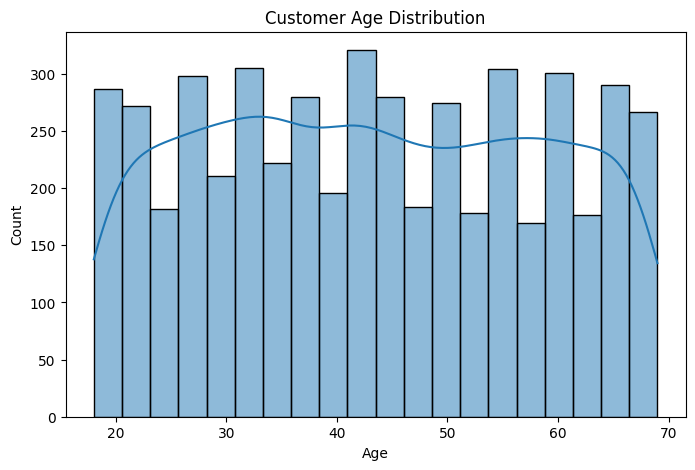

In [250]:
plt.figure(figsize=(8,5))
sns.histplot(customers['age'], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("../outputs/age_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

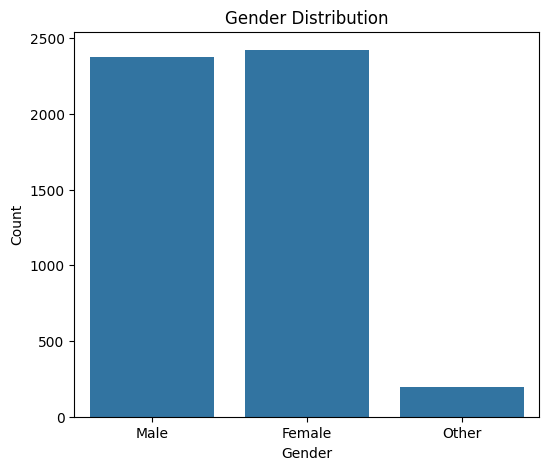

In [251]:
plt.figure(figsize=(6,5))
sns.countplot(data=customers, x='gender')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.savefig("../outputs/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

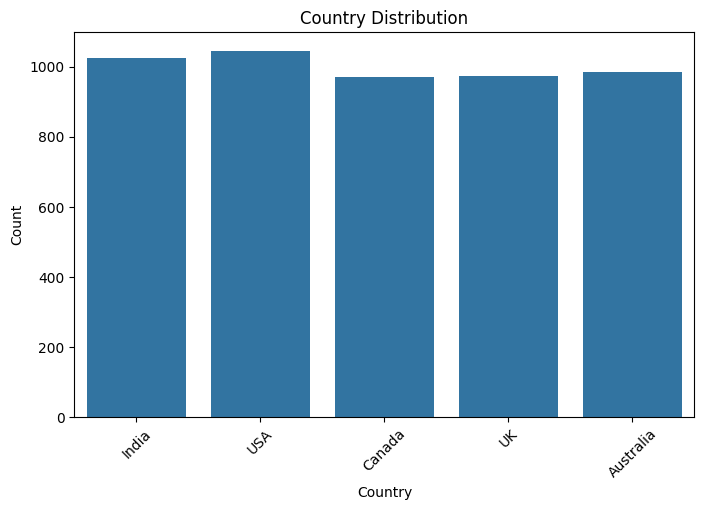

In [252]:
plt.figure(figsize=(8,5))
sns.countplot(data=customers, x='country')
plt.title("Country Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("../outputs/country_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

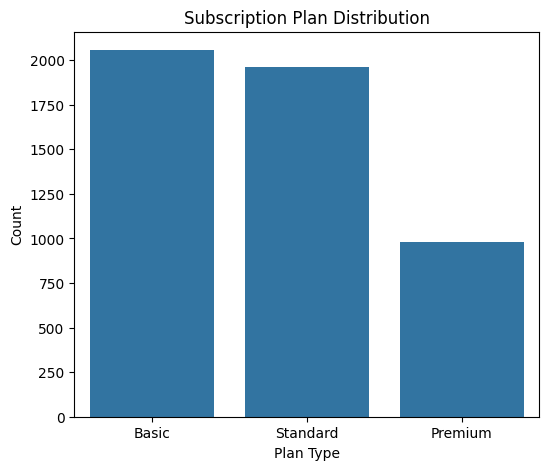

In [253]:
plt.figure(figsize=(6,5))
sns.countplot(data=customers, x='plan_type')
plt.title("Subscription Plan Distribution")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.savefig("../outputs/plan_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

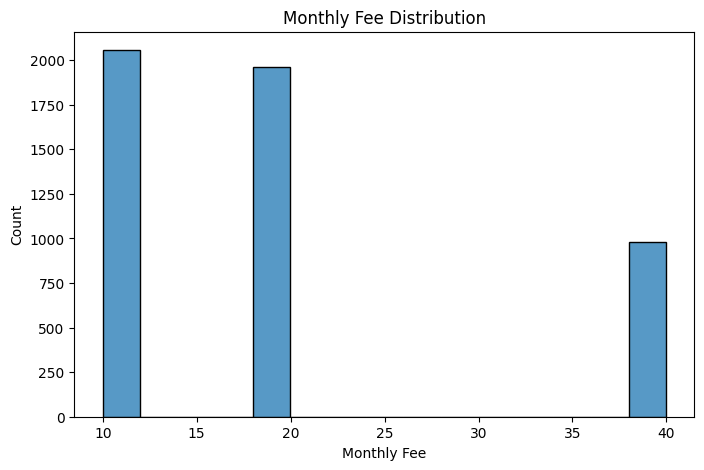

In [254]:
plt.figure(figsize=(8,5))
sns.histplot(customers['monthly_fee'], bins=15)
plt.title("Monthly Fee Distribution")
plt.xlabel("Monthly Fee")
plt.ylabel("Count")
plt.savefig("../outputs/monthly_fee_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

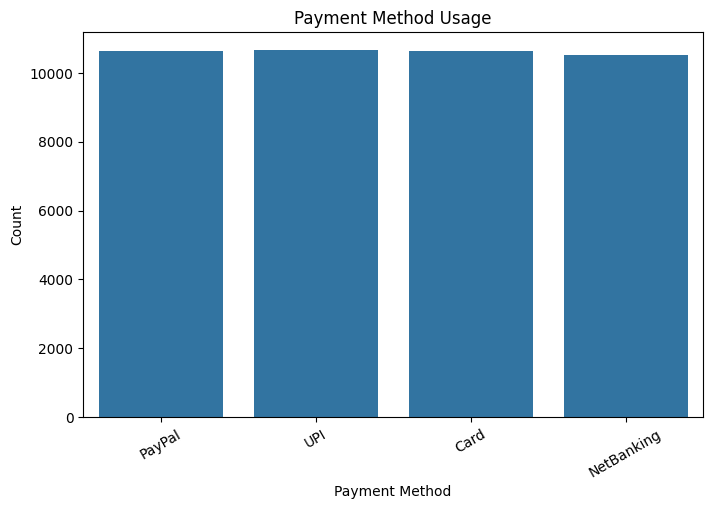

In [255]:
plt.figure(figsize=(8,5))
sns.countplot(data=transactions, x='payment_method')
plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.savefig("../outputs/payment_method_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

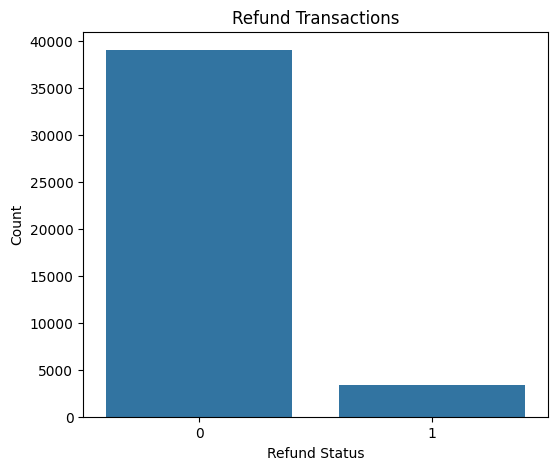

In [256]:
plt.figure(figsize=(6,5))
sns.countplot(data=transactions, x='is_refund')
plt.title("Refund Transactions")
plt.xlabel("Refund Status")
plt.ylabel("Count")
plt.savefig("../outputs/refund_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

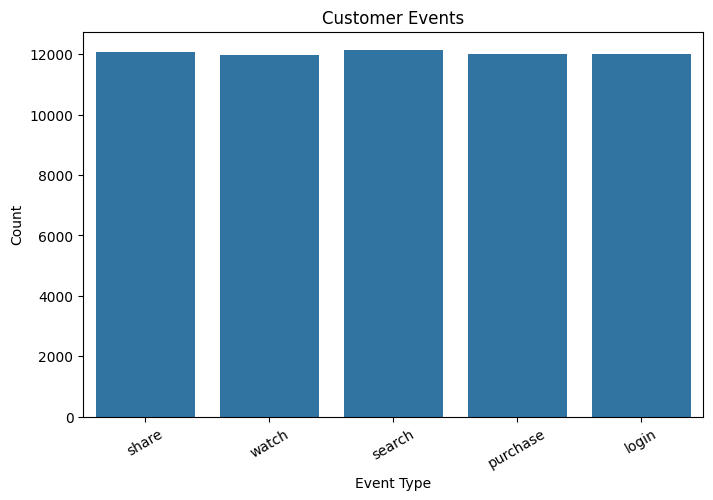

In [257]:
plt.figure(figsize=(8,5))
sns.countplot(data=events, x='event_type')
plt.title("Customer Events")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.savefig("../outputs/event_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

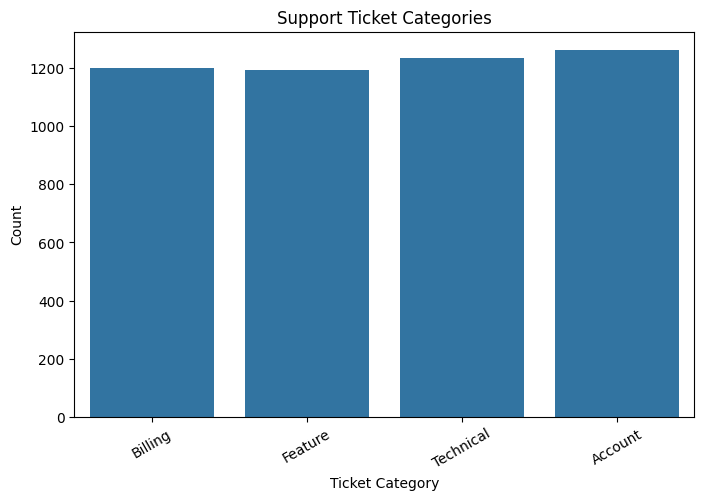

In [258]:
plt.figure(figsize=(8,5))
sns.countplot(data=support, x='ticket_category')
plt.title("Support Ticket Categories")
plt.xlabel("Ticket Category")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.savefig("../outputs/support_category_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

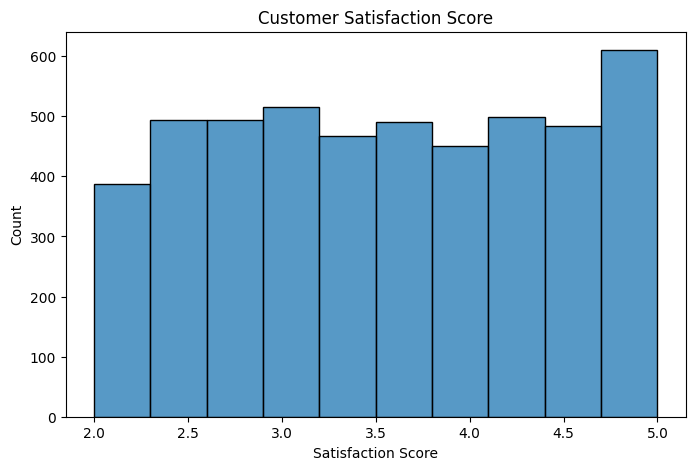

In [259]:
plt.figure(figsize=(8,5))
sns.histplot(support['satisfaction_score'], bins=10)
plt.title("Customer Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.savefig("../outputs/satisfaction_score_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

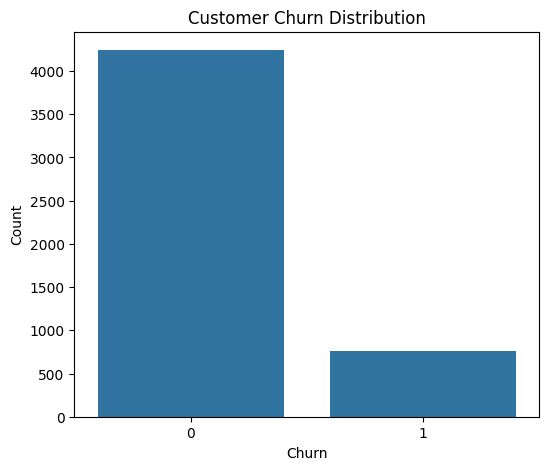

In [260]:
plt.figure(figsize=(6,5))
sns.countplot(data=churn, x='churn_30d')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.savefig("../outputs/churn_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

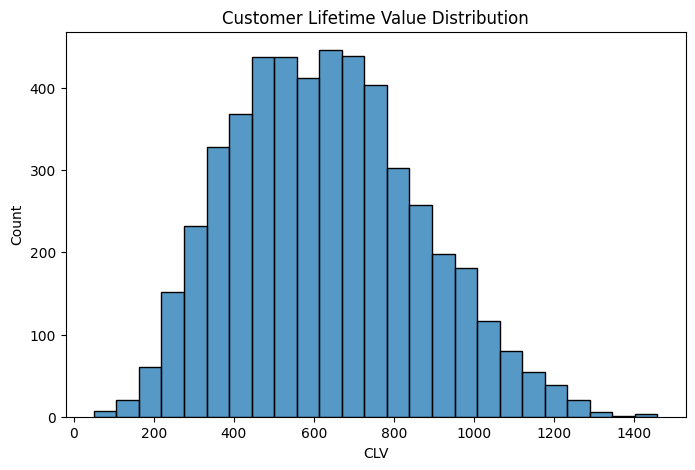

In [261]:
plt.figure(figsize=(8,5))
sns.histplot(clv['clv'], bins=25)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Count")
plt.savefig("../outputs/clv_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

# Feature Engineering

In [262]:
# Convert date columns
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
events['event_date'] = pd.to_datetime(events['event_date'])
support['ticket_date'] = pd.to_datetime(support['ticket_date'])

In [263]:
prediction_date = transactions['transaction_date'].max()
prediction_date

Timestamp('2025-10-31 00:00:00')

In [264]:
recency = transactions.groupby('customer_id')['transaction_date'].max().reset_index()
recency['Recency'] = (
    prediction_date - recency['transaction_date']
).dt.days
recency = recency[['customer_id', 'Recency']]
recency.head()

,customer_id,Recency
0,100001,161
1,100002,5
2,100003,35
3,100004,128
4,100005,549


In [265]:
frequency = transactions.groupby('customer_id').size().reset_index(name='Frequency')
frequency.head()

,customer_id,Frequency
0,100001,3
1,100002,12
2,100003,7
3,100004,10
4,100005,4


In [266]:
positive_transactions = transactions[
    transactions['is_refund'] == 0
]
monetary = positive_transactions.groupby('customer_id')['amount'].sum().reset_index()
monetary.rename(columns={'amount': 'Monetary'}, inplace=True)
monetary.head()

,customer_id,Monetary
0,100001,106.25
1,100002,519.09
2,100003,237.25
3,100004,457.28
4,100005,95.56


In [267]:
event_count = events.groupby('customer_id').size().reset_index(name='Event_Count')
event_count.head()

,customer_id,Event_Count
0,100001,10
1,100002,10
2,100003,13
3,100004,7
4,100005,19


In [268]:
avg_event = events.groupby('customer_id')['event_value'].mean().reset_index()
avg_event.rename(columns={'event_value': 'Avg_Event_Value'}, inplace=True)
avg_event.head()

,customer_id,Avg_Event_Value
0,100001,47.295000
1,100002,57.343000
2,100003,46.395385
3,100004,53.397143
4,100005,61.499474


In [269]:
ticket_count = support.groupby('customer_id').size().reset_index(name='Ticket_Count')
ticket_count.head()

,customer_id,Ticket_Count
0,100003,1
1,100004,3
2,100007,1
3,100011,1
4,100012,3


In [270]:
avg_satisfaction = support.groupby('customer_id')['satisfaction_score'].mean().reset_index()
avg_satisfaction.rename(
    columns={'satisfaction_score': 'Avg_Satisfaction'},
    inplace=True
)
avg_satisfaction.head()

,customer_id,Avg_Satisfaction
0,100003,4.500000
1,100004,2.933333
2,100007,3.000000
3,100011,5.000000
4,100012,3.266667


In [271]:
refund_count = transactions.groupby('customer_id')['is_refund'].sum().reset_index()
refund_count.rename(
    columns={'is_refund': 'Refund_Count'},
    inplace=True
)
refund_count.head()

,customer_id,Refund_Count
0,100001,0
1,100002,0
2,100003,0
3,100004,1
4,100005,1


In [272]:
customers['Tenure'] = (
    prediction_date - customers['signup_date']
).dt.days
customers[['customer_id', 'Tenure']].head()

,customer_id,Tenure
0,100001,273
1,100002,539
2,100003,269
3,100004,304
4,100005,355


In [273]:
features = customers.copy()
features = features.merge(recency, on='customer_id', how='left')
features = features.merge(frequency, on='customer_id', how='left')
features = features.merge(monetary, on='customer_id', how='left')
features = features.merge(event_count, on='customer_id', how='left')
features = features.merge(avg_event, on='customer_id', how='left')
features = features.merge(ticket_count, on='customer_id', how='left')
features = features.merge(avg_satisfaction, on='customer_id', how='left')
features = features.merge(refund_count, on='customer_id', how='left')

In [274]:
features.fillna(0, inplace=True)
features.head()

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee,Tenure,Recency,Frequency,Monetary,Event_Count,Avg_Event_Value,Ticket_Count,Avg_Satisfaction,Refund_Count
0,100001,2025-01-31,63,Male,India,Basic,9.99,273,161,3,106.25,10,47.295000,0.0,0.000000,0
1,100002,2024-05-10,43,Male,USA,Standard,19.99,539,5,12,519.09,10,57.343000,0.0,0.000000,0
2,100003,2025-02-04,65,Male,Canada,Standard,19.99,269,35,7,237.25,13,46.395385,1.0,4.500000,0
3,100004,2024-12-31,56,Male,UK,Premium,39.99,304,128,10,457.28,7,53.397143,3.0,2.933333,1
4,100005,2024-11-10,58,Male,India,Standard,19.99,355,549,4,95.56,19,61.499474,0.0,0.000000,1


In [275]:
features.shape

(5000, 16)

In [276]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       5000 non-null   int64         
 1   signup_date       5000 non-null   datetime64[ns]
 2   age               5000 non-null   int64         
 3   gender            5000 non-null   object        
 4   country           5000 non-null   object        
 5   plan_type         5000 non-null   object        
 6   monthly_fee       5000 non-null   float64       
 7   Tenure            5000 non-null   int64         
 8   Recency           5000 non-null   int64         
 9   Frequency         5000 non-null   int64         
 10  Monetary          5000 non-null   float64       
 11  Event_Count       5000 non-null   int64         
 12  Avg_Event_Value   5000 non-null   float64       
 13  Ticket_Count      5000 non-null   float64       
 14  Avg_Satisfaction  5000 n

In [277]:
features.head()

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee,Tenure,Recency,Frequency,Monetary,Event_Count,Avg_Event_Value,Ticket_Count,Avg_Satisfaction,Refund_Count
0,100001,2025-01-31,63,Male,India,Basic,9.99,273,161,3,106.25,10,47.295000,0.0,0.000000,0
1,100002,2024-05-10,43,Male,USA,Standard,19.99,539,5,12,519.09,10,57.343000,0.0,0.000000,0
2,100003,2025-02-04,65,Male,Canada,Standard,19.99,269,35,7,237.25,13,46.395385,1.0,4.500000,0
3,100004,2024-12-31,56,Male,UK,Premium,39.99,304,128,10,457.28,7,53.397143,3.0,2.933333,1
4,100005,2024-11-10,58,Male,India,Standard,19.99,355,549,4,95.56,19,61.499474,0.0,0.000000,1


# CLV Prediction (Regression)

## Objective

Build a regression model to predict Customer Lifetime Value (CLV) using customer demographics, subscription details, transaction history, engagement, and support features.

## Data Preparation

The engineered features are merged with the CLV labels using `customer_id` to create the final dataset for model training.

### Features
- Demographics
- Subscription Details
- RFM Features
- Engagement Features
- Support Features
- Refund Count

### Target
- **CLV (Customer Lifetime Value)**

In [278]:
# Merge CLV labels
clv_data = features.merge(clv, on='customer_id', how='inner')
clv_data.head()

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee,Tenure,Recency,Frequency,Monetary,Event_Count,Avg_Event_Value,Ticket_Count,Avg_Satisfaction,Refund_Count,clv
0,100001,2025-01-31,63,Male,India,Basic,9.99,273,161,3,106.25,10,47.295000,0.0,0.000000,0,274.01
1,100002,2024-05-10,43,Male,USA,Standard,19.99,539,5,12,519.09,10,57.343000,0.0,0.000000,0,924.84
2,100003,2025-02-04,65,Male,Canada,Standard,19.99,269,35,7,237.25,13,46.395385,1.0,4.500000,0,574.05
3,100004,2024-12-31,56,Male,UK,Premium,39.99,304,128,10,457.28,7,53.397143,3.0,2.933333,1,989.17
4,100005,2024-11-10,58,Male,India,Standard,19.99,355,549,4,95.56,19,61.499474,0.0,0.000000,1,322.91


### Observation

The merged dataset successfully combines engineered customer features with the corresponding CLV values. Each row represents a unique customer and includes demographic, behavioral, transactional, engagement, and support-related attributes along with the target CLV value.

This consolidated dataset is now ready for preprocessing, feature encoding, train-test splitting, and regression model development.

In [279]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
clv_data['gender'] = encoder.fit_transform(clv_data['gender'])
clv_data['country'] = encoder.fit_transform(clv_data['country'])
clv_data['plan_type'] = encoder.fit_transform(clv_data['plan_type'])

In [280]:
clv_data = clv_data.drop(['customer_id', 'signup_date'], axis=1)

In [281]:
X = clv_data.drop('clv', axis=1)
y = clv_data['clv']

In [282]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [283]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Training

A Random Forest Regressor was trained using the prepared customer dataset. The model learns relationships between customer demographics, subscription details, transaction behavior, engagement metrics, and support interactions to predict Customer Lifetime Value (CLV).

Random Forest was selected because it can capture complex non-linear relationships, handle feature interactions effectively, and provide robust predictive performance.

In [284]:
predictions = rf_model.predict(X_test)

In [285]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 41.64284754999999
RMSE : 52.068829170728115
R2 Score : 0.9490440181131942


## Model Evaluation

The Random Forest Regressor achieved strong predictive performance for Customer Lifetime Value (CLV). The low MAE and RMSE values indicate accurate predictions, while the high R² score shows that the model explains most of the variation in customer lifetime value.

### Evaluation Metrics

- **MAE:** 41.64
- **RMSE:** 52.07
- **R² Score:** 0.9490

### Observation

The model achieved an R² score of **94.90%**, indicating excellent predictive capability. The relatively low MAE and RMSE values suggest that the predicted CLV values are close to the actual values, making the model suitable for identifying high-value customers and supporting business decision-making.

## Feature Importance Analysis

Feature importance helps identify which variables have the greatest influence on Customer Lifetime Value (CLV) prediction. The Random Forest model ranks features based on their contribution to the prediction process.

The results show that customer spending behavior and subscription details are the most significant factors affecting CLV.

In [286]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
8,Monetary,0.645973
4,monthly_fee,0.292438
3,plan_type,0.022713
6,Recency,0.005970
10,Avg_Event_Value,0.005744
5,Tenure,0.005709
0,age,0.005161
9,Event_Count,0.003754
12,Avg_Satisfaction,0.003609
7,Frequency,0.002331


### Key Observations

- **Monetary (64.60%)** is the most influential feature for predicting CLV.
- **Monthly Fee (29.24%)** is the second most important factor.
- **Plan Type** also contributes to the prediction, while demographic and support-related features have comparatively lower importance.
- Customer spending patterns play a much larger role in determining lifetime value than age, gender, or support interactions.

## Feature Importance Visualization

The feature importance plot illustrates the relative contribution of each feature to the CLV prediction model. Higher importance values indicate a greater influence on the model's predictions.

The visualization shows that **Monetary** and **Monthly Fee** are the most significant factors driving Customer Lifetime Value, while demographic and support-related features have a comparatively smaller impact.

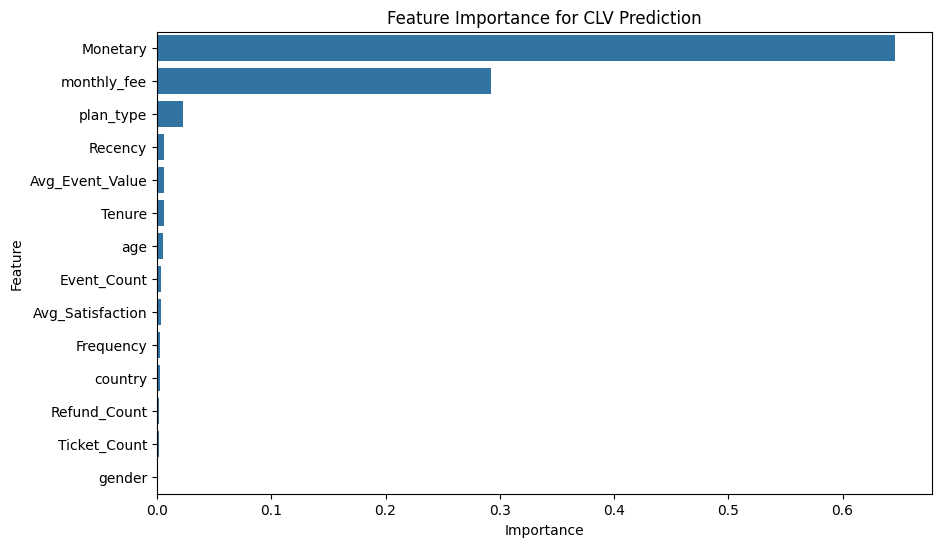

In [287]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance for CLV Prediction")
plt.savefig("../outputs/clv_feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Observations

- **Monetary** is the dominant feature, contributing the most to CLV prediction.
- **Monthly Fee** is the second most influential feature.
- **Plan Type** has a moderate impact on customer lifetime value.
- Features such as **Age, Event Count, Satisfaction Score, Frequency, Country, Refund Count, Ticket Count, and Gender** have relatively low importance.

These results indicate that customer spending behavior is the primary driver of lifetime value.

# Churn Prediction (Classification)

## Objective

The objective of this section is to build a classification model that predicts whether a customer is likely to churn within the next 30 days based on demographic, subscription, transaction, engagement, and support-related features.

# Churn Prediction (Classification)

## Objective

Build a classification model to predict whether a customer is likely to churn within the next 30 days using customer demographics, subscription details, transaction history, engagement, and support features.

## Data Preparation

The engineered feature dataset is merged with the churn labels using `customer_id`, creating the final dataset for churn prediction.

In [288]:
# Merge churn labels
churn_data = features.merge(churn, on='customer_id', how='inner')
churn_data.head()

,customer_id,signup_date,age,gender,country,plan_type,monthly_fee,Tenure,Recency,Frequency,Monetary,Event_Count,Avg_Event_Value,Ticket_Count,Avg_Satisfaction,Refund_Count,churn_30d
0,100001,2025-01-31,63,Male,India,Basic,9.99,273,161,3,106.25,10,47.295000,0.0,0.000000,0,1
1,100002,2024-05-10,43,Male,USA,Standard,19.99,539,5,12,519.09,10,57.343000,0.0,0.000000,0,0
2,100003,2025-02-04,65,Male,Canada,Standard,19.99,269,35,7,237.25,13,46.395385,1.0,4.500000,0,0
3,100004,2024-12-31,56,Male,UK,Premium,39.99,304,128,10,457.28,7,53.397143,3.0,2.933333,1,0
4,100005,2024-11-10,58,Male,India,Standard,19.99,355,549,4,95.56,19,61.499474,0.0,0.000000,1,0


### Observation

The merged dataset successfully combines customer features with the churn target (`churn_30d`). Each record contains customer information, behavioral metrics, and the corresponding churn label, making it suitable for training and evaluating a classification model.

### Business Insight

By combining customer demographics, spending behavior, engagement metrics, and support history, the dataset provides a comprehensive view of customer activity. This enables the model to identify customers who are at risk of churning and supports proactive retention strategies.

In [289]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
churn_data['gender'] = encoder.fit_transform(churn_data['gender'])
churn_data['country'] = encoder.fit_transform(churn_data['country'])
churn_data['plan_type'] = encoder.fit_transform(churn_data['plan_type'])

In [290]:
churn_data = churn_data.drop(['customer_id', 'signup_date'], axis=1)

In [291]:
X = churn_data.drop('churn_30d', axis=1)
y = churn_data['churn_30d']

In [292]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Training

A Random Forest Classifier was trained using the prepared customer dataset to predict customer churn. The model learns patterns from customer demographics, subscription details, transaction behavior, engagement metrics, and support interactions to classify customers as likely to churn or retain.

In [293]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
classifier.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Observation

The Random Forest Classifier was successfully fitted on the training dataset and is now ready to generate predictions on unseen data. This model is expected to capture complex relationships between customer behavior and churn probability.

In [294]:
predictions = classifier.predict(X_test)

In [295]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, predictions)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC-AUC :", roc_auc)

Accuracy : 0.894
Precision : 0.7272727272727273
Recall : 0.4768211920529801
F1 Score : 0.576
ROC-AUC : 0.7225095359558187


## Model Evaluation

The Random Forest Classifier was evaluated using standard classification metrics to measure its ability to identify customers who are likely to churn.

### Evaluation Metrics

- **Accuracy:** 89.40%
- **Precision:** 72.73%
- **Recall:** 47.68%
- **F1 Score:** 57.60%
- **ROC-AUC Score:** 72.25%

### Observations

- The model achieved an overall accuracy of **89.40%**, indicating strong classification performance.
- A precision score of **72.73%** shows that most customers predicted as churners actually churn.
- The recall score of **47.68%** indicates that nearly half of the actual churners are successfully identified.
- The ROC-AUC score of **72.25%** demonstrates a good ability to distinguish between churning and retained customers.

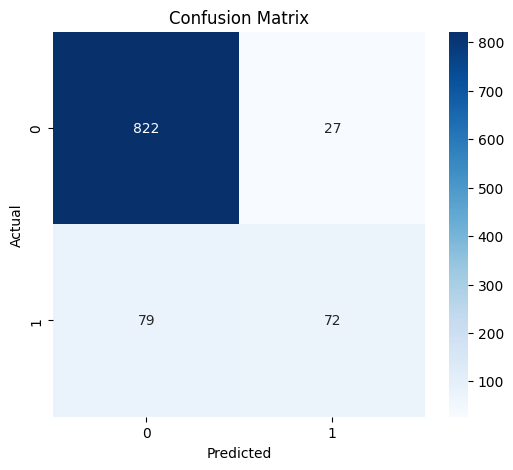

In [296]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../outputs/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## Confusion Matrix Analysis

The confusion matrix summarizes the classification performance of the model by comparing predicted labels with actual customer outcomes.

### Results

- **True Negatives (822):** Correctly identified retained customers.
- **True Positives (72):** Correctly identified churned customers.
- **False Positives (27):** Retained customers incorrectly predicted as churners.
- **False Negatives (79):** Churned customers incorrectly predicted as retained.

The model performs well in identifying retained customers but has room for improvement in detecting all potential churners.

In [297]:
importance = pd.DataFrame({
    'Feature': X.columns,

    'Importance': classifier.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
13,Refund_Count,0.316204
8,Monetary,0.086590
5,Tenure,0.082812
10,Avg_Event_Value,0.078910
6,Recency,0.075699
0,age,0.070408
7,Frequency,0.051481
9,Event_Count,0.049594
12,Avg_Satisfaction,0.045640
3,plan_type,0.036893


## Feature Importance Analysis

Feature importance identifies the variables that contribute most to customer churn prediction.

The Random Forest model indicates that refund behavior, customer spending, and tenure are the most influential factors affecting churn probability.

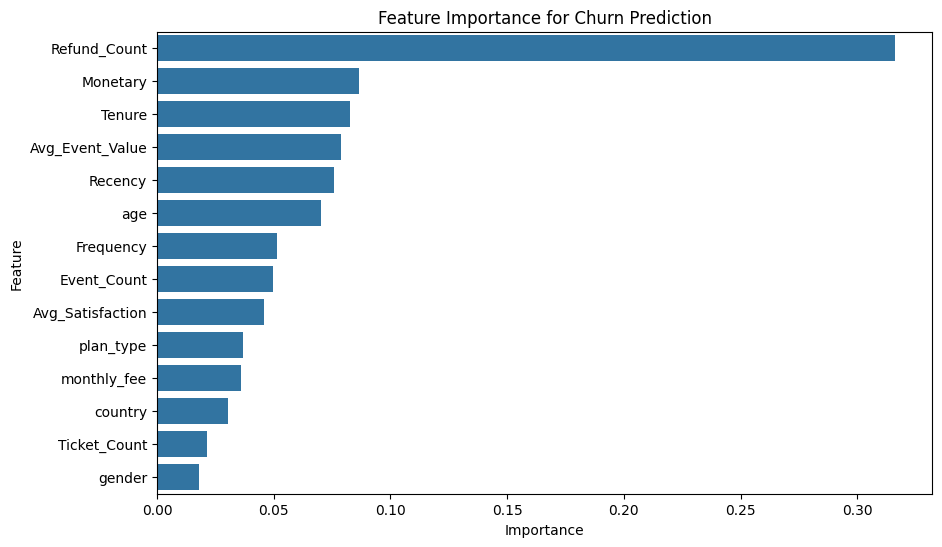

In [298]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance for Churn Prediction")
plt.savefig("../outputs/churn_feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Key Observations

- **Refund Count (31.62%)** is the most influential feature for predicting churn.
- **Monetary Value (8.66%)** and **Tenure (8.28%)** are also strong predictors.
- Customer engagement metrics such as **Average Event Value** and **Recency** contribute significantly to churn prediction.
- Demographic features like **Gender** and **Country** have relatively low impact on customer churn.

### Business Insights

- Customers with frequent refunds are at a significantly higher risk of churn.
- Customers with lower spending and shorter tenure require additional engagement and retention efforts.
- Improving customer satisfaction and reducing refund requests can help decrease churn rates.
- Personalized retention campaigns targeting high-risk customers can improve long-term customer loyalty.

# Conclusion

This project successfully developed machine learning models for Customer Lifetime Value (CLV) prediction and Customer Churn prediction using customer demographics, subscription details, transaction history, engagement metrics, and support information.

The CLV Regression model achieved an **R² Score of 94.90%**, demonstrating excellent predictive performance. The Churn Classification model achieved an **Accuracy of 89.40%** and a **ROC-AUC Score of 72.25%**, effectively identifying customers at risk of churn.

Feature importance analysis revealed that **Monetary Value** is the strongest predictor of CLV, while **Refund Count** is the most influential factor for churn prediction.

These insights can help businesses identify high-value customers, reduce churn through targeted retention strategies, optimize subscription plans, and improve long-term customer relationships.

# Recommendations

- Focus on increasing customer spending to improve Customer Lifetime Value.
- Encourage customers to upgrade to premium subscription plans.
- Monitor refund behavior and proactively engage customers with frequent refunds.
- Design personalized retention campaigns for customers with low tenure and low engagement.
- Continuously track customer behavior using predictive analytics to improve retention and maximize business revenue.